In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('data/superstore.csv')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,9/11/2013,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,9/11/2013,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11/10/2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11/10/2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


#### Data Cleaning

In [6]:
# Check missing values

In [7]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
# Remove duplicates
df = df.drop_duplicates()

In [9]:
# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst = True)

In [10]:
# Create Month column
df['Month'] = df['Order Date'].dt.month_name()

In [11]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
0,1,CA-2013-152156,2013-11-09,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November
1,2,CA-2013-152156,2013-11-09,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November
2,3,CA-2013-138688,2013-06-13,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June
3,4,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October
4,5,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October


In [12]:
# Create Year column
df['Year'] = df['Order Date'].dt.year

In [13]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
0,1,CA-2013-152156,2013-11-09,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November,2013
1,2,CA-2013-152156,2013-11-09,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November,2013
2,3,CA-2013-138688,2013-06-13,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June,2013
3,4,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October,2012
4,5,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October,2012


#### Exploratory Data Analysis

In [10]:
# Total Sales
df['Total Sales'] = df['Sales'].sum()

In [11]:
# Total Profit
df['Total_Profit'] = df['Profit'].sum()


In [12]:
# Average Sales
df['Avg_Sales'] = df['Sales'].mean()


In [15]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Month,Year,Total Sales,Total_Profit,Avg_Sales
0,1,CA-2013-152156,2013-11-09,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November,2013,2.297201e+06,286397.0217,229.858001
1,2,CA-2013-152156,2013-11-09,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November,2013,2.297201e+06,286397.0217,229.858001
2,3,CA-2013-138688,2013-06-13,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June,2013,2.297201e+06,286397.0217,229.858001
3,4,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October,2012,2.297201e+06,286397.0217,229.858001
4,5,US-2012-108966,2012-10-11,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October,2012,2.297201e+06,286397.0217,229.858001


In [ ]:
# Which category generates the highest sales

In [ ]:
sales_by_Category = df.groupby('Category')['Sales'].sum().reset_index()

In [32]:
sales_by_Category

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


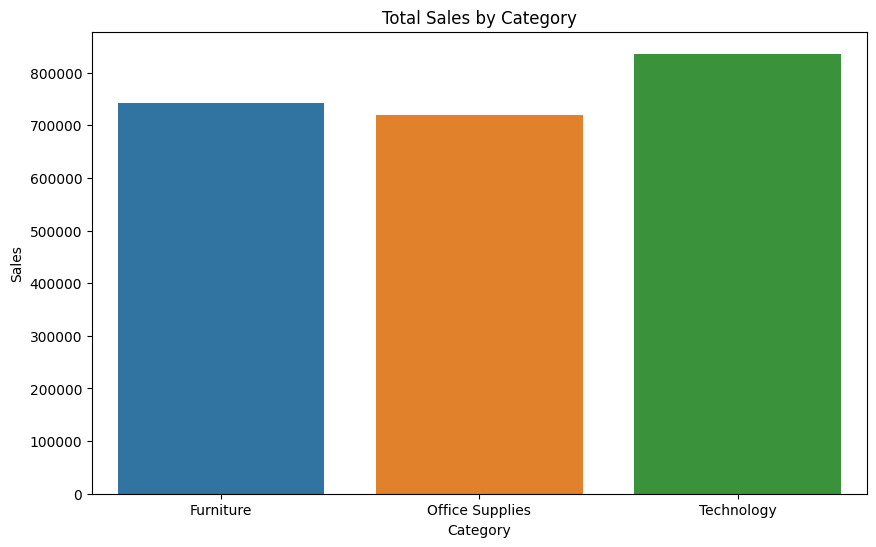

In [33]:
sales_by_region = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Category', 
    y='Sales', 
    data=sales_by_region,
    hue='Category'
)
plt.title('Total Sales by Category')
plt.show()

In [ ]:
# Which region is most profitable?

In [37]:
profit_by_region = df.groupby('Region')['Profit'].sum().reset_index()

In [38]:
profit_by_region

,Region,Profit
0,Central,39706.3625
1,East,91522.7800
2,South,46749.4303
3,West,108418.4489


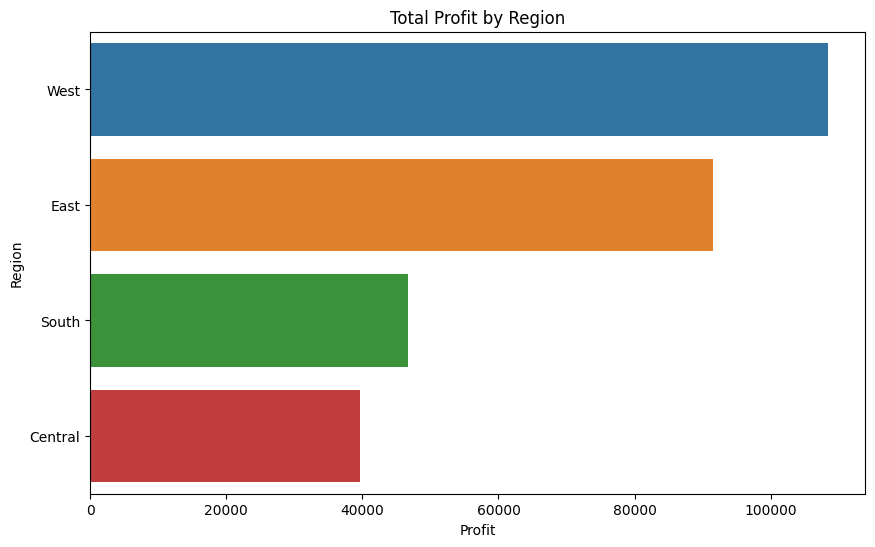

In [54]:
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Profit', y='Region', data=profit_by_region, hue='Region')
plt.title('Total Profit by Region')
plt.show()

In [ ]:
# Which products perform best?

In [56]:
top_10_product = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

In [59]:
top_10_product.head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

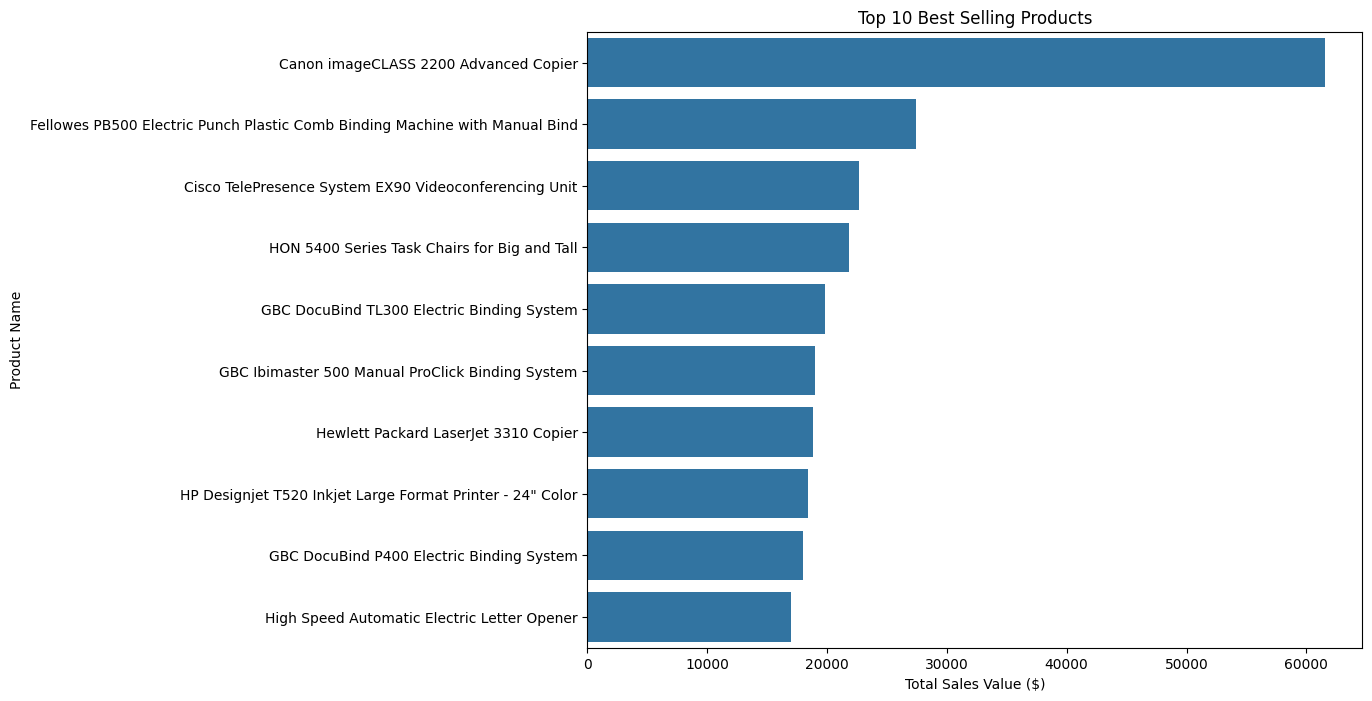

In [67]:
top_10_product = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).reset_index().head(10)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_10_product, 
    x='Sales', 
    y='Product Name', 
            
)

plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Sales Value ($)')
plt.ylabel('Product Name')
plt.show()

In [16]:
# Sales by Category Visualization

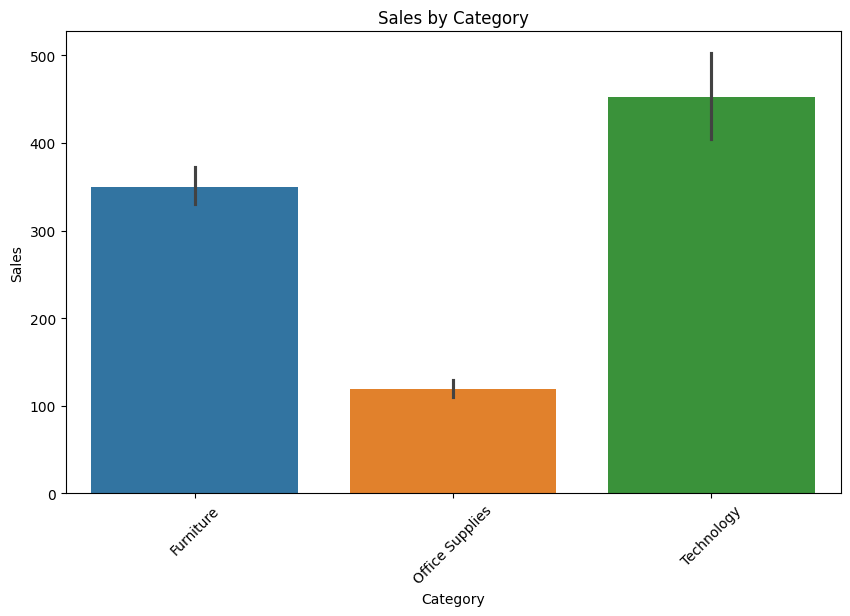

In [29]:
plt.figure(figsize = (10, 6))

sns.barplot(
        x='Category',
        y='Sales',
        hue='Category',
        data=df
)
plt.title('Sales by Category')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Total Sales by Region

In [24]:
sales_by_region = df.groupby('Region')['Sales'].sum().reset_index()

In [79]:
sales_by_region

,Region,Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


<Axes: xlabel='Region'>

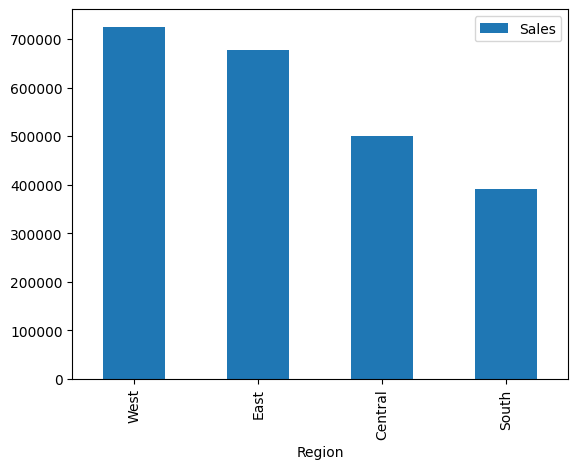

In [82]:
sales_by_region.sort_values(by='Sales', ascending=False).plot(kind='bar', x='Region', y='Sales')


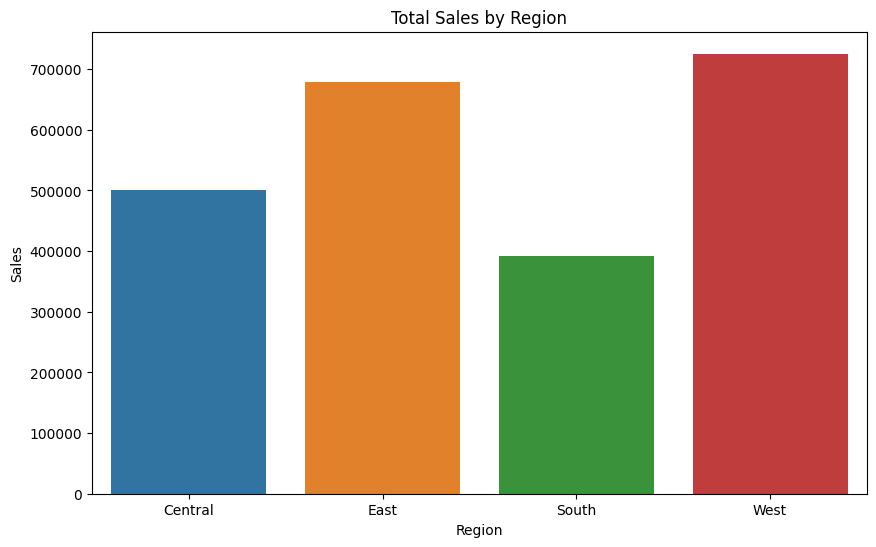

In [22]:
sales_by_region = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Region', 
    y='Sales', 
    data=sales_by_region,
    hue='Region'
)
plt.title('Total Sales by Region')
plt.show()

In [19]:
# Monthly Sales Trend

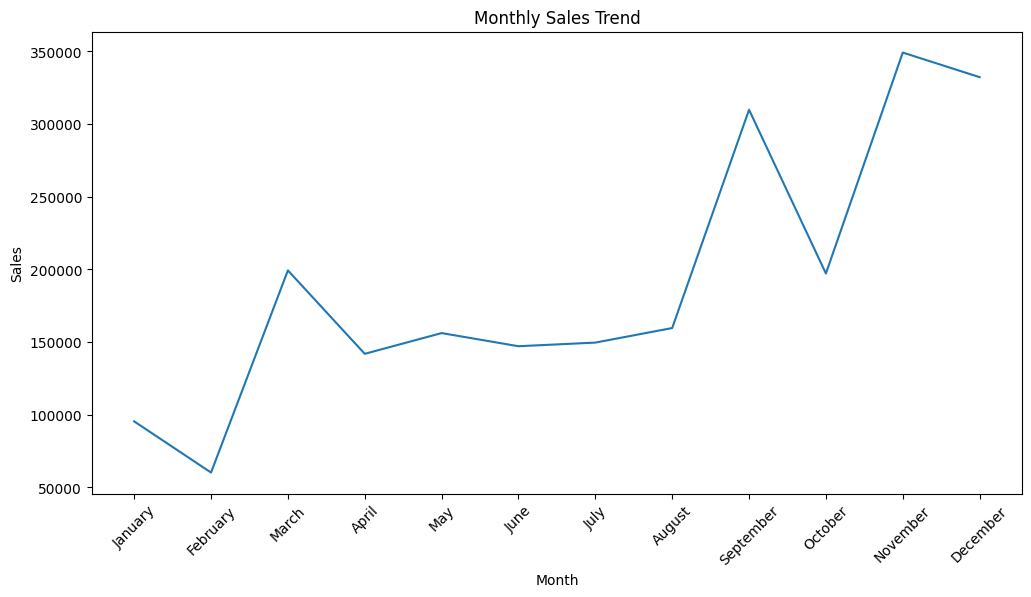

In [15]:
df['MonthNum'] = df['Order Date'].dt.month
monthly_sales = df.groupby(['MonthNum', 'Month'])['Sales'].sum().reset_index()
monthly_sales = monthly_sales.sort_values('MonthNum')
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Sales', data=monthly_sales)
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()

In [21]:
# Interactive Plotly Charts

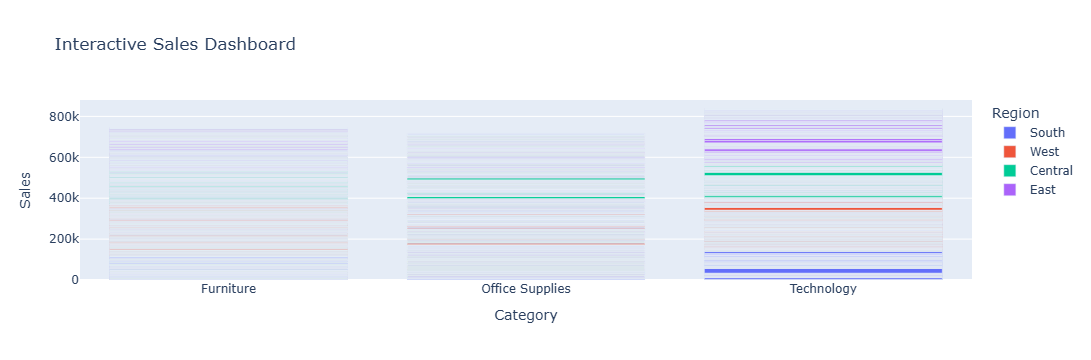

In [22]:
fig = px.bar(df, x='Category', y='Sales', color='Region', title='Interactive Sales Dashboard')
fig.show()